Step 1: Dataset Creation

In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Categories
categories = {
    "Software Issue": [
        "Application crashing frequently",
        "Unable to install software update",
        "Software license expired"
    ],

    "Hardware Issue": [
        "Laptop not turning on",
        "Keyboard not working properly",
        "Monitor display flickering"
    ],

    "VPN Access": [
        "VPN connection failed remotely",
        "Unable to connect to company VPN",
        "VPN disconnecting repeatedly"
    ],

    "Password Reset": [
        "Forgot system password",
        "Password reset link not working",
        "Unable to login after password reset"
    ],

    "Email Issue": [
        "Outlook not syncing emails",
        "Unable to send company email",
        "Email attachments not opening"
    ],

    "Network Issue": [
        "Internet speed extremely slow",
        "WiFi disconnecting frequently",
        "Unable to access internal network"
    ],

    "Database Issue": [
        "SQL server connection timeout",
        "Database query execution failed",
        "Unable to connect to database"
    ],

    "Cloud Issue": [
        "AWS server instance down",
        "Azure VM not responding",
        "Cloud storage access denied"
    ],

    "Security Incident": [
        "Suspicious login detected",
        "Malware alert triggered",
        "Unauthorized access attempt"
    ],

    "Application Bug": [
        "Dashboard not loading correctly",
        "API returning unexpected error",
        "Form submission failed"
    ]
}

# Priority options
priority_levels = ["Low", "Medium", "High", "Critical"]

# Teams
teams = [
    "IT Support",
    "Network Team",
    "Security Team",
    "Database Team",
    "Cloud Team",
    "Application Team"
]

# Status
status_list = ["Open", "In Progress", "Resolved", "Closed"]

# Generate data
data = []

for i in range(5000):

    category = random.choice(list(categories.keys()))

    description = random.choice(categories[category])

    priority = random.choice(priority_levels)

    resolution_time = round(random.uniform(1, 12), 2)

    team = random.choice(teams)

    status = random.choice(status_list)

    date = datetime.now() - timedelta(days=random.randint(1, 365))

    data.append([
        1000 + i,
        description,
        category,
        priority,
        resolution_time,
        team,
        status,
        date.date()
    ])

# Create dataframe
df = pd.DataFrame(data, columns=[
    "ticket_id",
    "ticket_description",
    "category",
    "priority",
    "resolution_time_hours",
    "assigned_team",
    "status",
    "created_date"
])

# Save dataset
df.to_csv("../data/tickets_dataset.csv", index=False)

print("Dataset created successfully")

df.head()

Dataset created successfully


,ticket_id,ticket_description,category,priority,resolution_time_hours,assigned_team,status,created_date
0,1000,VPN connection failed remotely,VPN Access,Medium,2.12,Cloud Team,In Progress,2026-02-04
1,1001,Unable to connect to company VPN,VPN Access,Critical,3.57,Cloud Team,Resolved,2026-03-05
2,1002,Form submission failed,Application Bug,Medium,10.68,Database Team,Open,2026-06-09
3,1003,Unable to connect to company VPN,VPN Access,Medium,10.94,Network Team,Closed,2025-09-09
4,1004,Password reset link not working,Password Reset,Low,10.21,Cloud Team,Open,2026-02-17


Step 2 — Load Dataset and Inspect

In [2]:
import pandas as pd

df = pd.read_csv("../data/tickets_dataset.csv")

df.head()

,ticket_id,ticket_description,category,priority,resolution_time_hours,assigned_team,status,created_date
0,1000,VPN connection failed remotely,VPN Access,Medium,2.12,Cloud Team,In Progress,2026-02-04
1,1001,Unable to connect to company VPN,VPN Access,Critical,3.57,Cloud Team,Resolved,2026-03-05
2,1002,Form submission failed,Application Bug,Medium,10.68,Database Team,Open,2026-06-09
3,1003,Unable to connect to company VPN,VPN Access,Medium,10.94,Network Team,Closed,2025-09-09
4,1004,Password reset link not working,Password Reset,Low,10.21,Cloud Team,Open,2026-02-17


In [3]:
print(df.shape)

(5000, 8)


Step 3 — Basic Dataset Check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              5000 non-null   int64  
 1   ticket_description     5000 non-null   object 
 2   category               5000 non-null   object 
 3   priority               5000 non-null   object 
 4   resolution_time_hours  5000 non-null   float64
 5   assigned_team          5000 non-null   object 
 6   status                 5000 non-null   object 
 7   created_date           5000 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 312.6+ KB


Check missing values

In [5]:
df.isnull().sum()

ticket_id                0
ticket_description       0
category                 0
priority                 0
resolution_time_hours    0
assigned_team            0
status                   0
created_date             0
dtype: int64

Step 4 — Category Distribution

In [6]:
df["category"].value_counts()

category
Network Issue        516
Hardware Issue       514
VPN Access           513
Password Reset       506
Database Issue       506
Application Bug      499
Email Issue          498
Cloud Issue          493
Software Issue       486
Security Incident    469
Name: count, dtype: int64

Plot

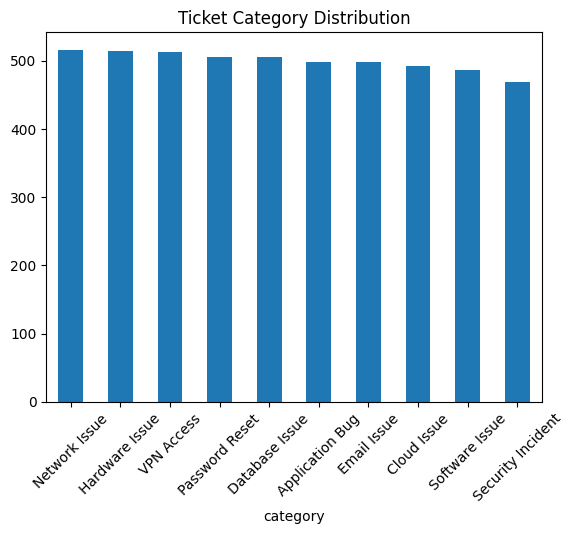

In [7]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")

plt.title("Ticket Category Distribution")

plt.xticks(rotation=45)

plt.show()

Step 5 — Priority Distribution

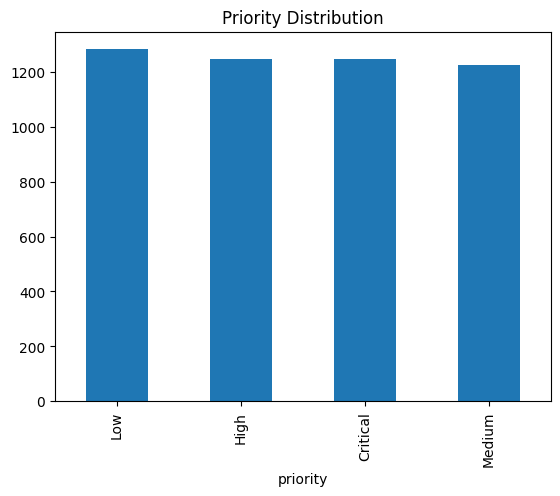

In [8]:
df["priority"].value_counts().plot(kind="bar")

plt.title("Priority Distribution")

plt.show()

Step 6 — Text Cleaning (NLP preprocessing)

In [9]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    stop_words = set(stopwords.words("english"))

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
df["cleaned_text"] = df["ticket_description"].apply(clean_text)

df[["ticket_description","cleaned_text"]].head()

,ticket_description,cleaned_text
0,VPN connection failed remotely,vpn connection failed remotely
1,Unable to connect to company VPN,unable connect company vpn
2,Form submission failed,form submission failed
3,Unable to connect to company VPN,unable connect company vpn
4,Password reset link not working,password reset link working


Step 7 — Save Processed Dataset

In [11]:
df.to_csv("../data/processed_tickets.csv", index=False)

print("Processed dataset saved")

Processed dataset saved


Phase 3 — Build ML Models

We will train 3 separate models.

Model 1 → Ticket Categorization (NLP Classification)
Model 2 → Priority Prediction (Classification)
Model 3 → Resolution Time Prediction (Regression)

Model 1 — Ticket Categorization

Step 1 — TF-IDF Vectorization

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df["cleaned_text"])

print(X.shape)

(5000, 76)


Step 2 — Encode Target Labels

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["category"])

print(label_encoder.classes_)

['Application Bug' 'Cloud Issue' 'Database Issue' 'Email Issue'
 'Hardware Issue' 'Network Issue' 'Password Reset' 'Security Incident'
 'Software Issue' 'VPN Access']


Step 3 — Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 4 — Train Model

We start with Random Forest.

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Training complete")

Training complete


Step 5 — Prediction

In [16]:
predictions = model.predict(X_test)

Step 6 — Accuracy

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


Step 7 — Classification Report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       1.00      1.00      1.00        87
           2       1.00      1.00      1.00        88
           3       1.00      1.00      1.00        96
           4       1.00      1.00      1.00       108
           5       1.00      1.00      1.00       103
           6       1.00      1.00      1.00       101
           7       1.00      1.00      1.00        88
           8       1.00      1.00      1.00       106
           9       1.00      1.00      1.00       109

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Step 8 — Save Model

In [19]:
import joblib

joblib.dump(model, "../models/ticket_category_model.pkl")

joblib.dump(tfidf, "../models/tfidf.pkl")

joblib.dump(label_encoder, "../models/category_encoder.pkl")

print("Model saved")

Model saved


Phase 4 — Priority Prediction Model

Step 1 — Encode Priority

In [20]:
priority_encoder = LabelEncoder()

y_priority = priority_encoder.fit_transform(df["priority"])

print(priority_encoder.classes_)

['Critical' 'High' 'Low' 'Medium']


Step 2 — Train/Test Split

We will reuse same TF-IDF features (X).

In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

Step 3 — Train Model

In [22]:
priority_model = RandomForestClassifier()

priority_model.fit(X_train, y_train)

print("Priority model trained")

Priority model trained


Step 4 — Prediction

In [23]:
predictions = priority_model.predict(X_test)

Step 5 — Accuracy

In [24]:
accuracy = accuracy_score(y_test, predictions)

print("Priority Prediction Accuracy:", accuracy)

Priority Prediction Accuracy: 0.238


Step 6 — Classification Report

In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.25      0.24      0.25       265
           1       0.22      0.25      0.23       245
           2       0.24      0.24      0.24       242
           3       0.24      0.22      0.23       248

    accuracy                           0.24      1000
   macro avg       0.24      0.24      0.24      1000
weighted avg       0.24      0.24      0.24      1000



Step 7 — Save Model

In [26]:
joblib.dump(
    priority_model,
    "../models/priority_model.pkl"
)

joblib.dump(
    priority_encoder,
    "../models/priority_encoder.pkl"
)

print("Priority model saved")

Priority model saved


Phase 5 — Resolution Time Prediction (Regression)

Step 1 — Target Variable

In [27]:
y_resolution = df["resolution_time_hours"]

print(y_resolution.head())

0     2.12
1     3.57
2    10.68
3    10.94
4    10.21
Name: resolution_time_hours, dtype: float64


Step 2 — Train Test Split

We reuse same TF-IDF features (X).

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_resolution,
    test_size=0.2,
    random_state=42
)

Step 3 — Train Regression Model

Use Random Forest Regressor.

In [29]:
from sklearn.ensemble import RandomForestRegressor

resolution_model = RandomForestRegressor()

resolution_model.fit(X_train, y_train)

print("Resolution model trained")

Resolution model trained


Step 4 — Predict

In [30]:
predictions = resolution_model.predict(X_test)

Step 5 — Evaluate Model

Use MAE (Mean Absolute Error)

In [31]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 2.7144758837680567


Step 6 — R² Score

In [32]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: -0.004708027004788784


Step 7 — Save Model

In [33]:
import joblib

joblib.dump(
    resolution_model,
    "../models/resolution_model.pkl"
)

print("Resolution model saved")

Resolution model saved


Phase 6 — Similar Ticket Retrieval (RAG)

Goal:
New Ticket comes in

↓

Find similar historical tickets

↓

Retrieve past resolutions

↓

Use that as context for GenAI answer

Example:
Input:
"VPN disconnecting repeatedly while working remotely"

System finds:

Ticket 1023 → VPN authentication failed  
Ticket 2345 → Remote VPN tunnel issue  
Ticket 4512 → Cisco VPN reconnect problem

Architecture:

User Query
    ↓

Embedding Model
    ↓

Vector Database
    ↓

Similarity Search
    ↓

Top 3 Similar Tickets

I will use:

Sentence Transformers (MiniLM)

FAISS Vector Database

Install Libraries

In [34]:
!pip install sentence-transformers faiss-cpu

Step 1 — Load Dataset

In [35]:
import pandas as pd

df = pd.read_csv("../data/processed_tickets.csv")

df.head()

,ticket_id,ticket_description,category,priority,resolution_time_hours,assigned_team,status,created_date,cleaned_text
0,1000,VPN connection failed remotely,VPN Access,Medium,2.12,Cloud Team,In Progress,2026-02-04,vpn connection failed remotely
1,1001,Unable to connect to company VPN,VPN Access,Critical,3.57,Cloud Team,Resolved,2026-03-05,unable connect company vpn
2,1002,Form submission failed,Application Bug,Medium,10.68,Database Team,Open,2026-06-09,form submission failed
3,1003,Unable to connect to company VPN,VPN Access,Medium,10.94,Network Team,Closed,2025-09-09,unable connect company vpn
4,1004,Password reset link not working,Password Reset,Low,10.21,Cloud Team,Open,2026-02-17,password reset link working


Step 2 — Load Embedding Model

In [36]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded")

c:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
W0620 15:27:27.035756 28900 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\huggingface_hub\file_do

Embedding model loaded


Step 3 — Create Embeddings

We convert ticket descriptions into vectors.

In [37]:
ticket_embeddings = embedding_model.encode(
    df["ticket_description"].tolist()
)

print(ticket_embeddings.shape)

(5000, 384)


Step 4 — Create FAISS Index

In [38]:
import faiss
import numpy as np

dimension = ticket_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(ticket_embeddings))

print("FAISS index created")

FAISS index created


Step 5 — Save Index

In [39]:
faiss.write_index(
    index,
    "../models/ticket_faiss.index"
)

print("FAISS index saved")

FAISS index saved


Step 6 — Similar Ticket Search Function

In [41]:
def retrieve_similar_tickets(query):

    query_embedding = embedding_model.encode([query])

    distances, indices = index.search(
        np.array(query_embedding),
        k=3
    )

    results = df.iloc[indices[0]]

    return results

Step 7 — Test It

In [42]:
query = "VPN connection failed while working remotely"

results = retrieve_similar_tickets(query)

print(results[
    ["ticket_description","category"]
])

                 ticket_description    category
0    VPN connection failed remotely  VPN Access
113  VPN connection failed remotely  VPN Access
116  VPN connection failed remotely  VPN Access


Phase 7 — GenAI Auto Resolution Generator

Goal:

User submits new ticket

↓

Find similar past tickets using FAISS

↓

Use retrieved context

↓

Generate intelligent resolution steps automatically

Example:

Input:

VPN connection failed while working remotely

Output:

1. Check internet connectivity
2. Verify VPN credentials
3. Restart VPN client
4. Reconnect to corporate network
5. Contact network team if issue persists
This simulates LLM-based enterprise ticket automation.

simple version (LLM simulation)

Create function.

In [43]:
def generate_ai_resolution(ticket_query, retrieved_tickets):

    category = retrieved_tickets.iloc[0]["category"]

    solutions = {

        "VPN Access": [
            "Check internet connectivity",
            "Verify VPN credentials",
            "Restart VPN client",
            "Reconnect and test again"
        ],

        "Password Reset": [
            "Verify user identity",
            "Generate password reset link",
            "Reset temporary password",
            "Ask user to login again"
        ],

        "Email Issue": [
            "Check mailbox synchronization",
            "Verify Outlook configuration",
            "Restart mail client",
            "Check server connectivity"
        ],

        "Database Issue": [
            "Check database server status",
            "Verify connection string",
            "Restart database service",
            "Test query execution"
        ],

        "Network Issue": [
            "Check router connectivity",
            "Verify DNS configuration",
            "Restart network service",
            "Check firewall rules"
        ],

        "Security Incident": [
            "Block suspicious activity",
            "Run malware scan",
            "Check unauthorized access logs",
            "Escalate to security team"
        ]
    }

    if category in solutions:

        steps = solutions[category]

    else:

        steps = [
            "Analyze issue",
            "Escalate to support team"
        ]

    response = "Recommended Resolution Steps:\n\n"

    for i, step in enumerate(steps):

        response += f"{i+1}. {step}\n"

    return response

Test function

In [44]:
query = "VPN connection failed while working remotely"

retrieved = retrieve_similar_tickets(query)

response = generate_ai_resolution(
    query,
    retrieved
)

print(response)

Recommended Resolution Steps:

1. Check internet connectivity
2. Verify VPN credentials
3. Restart VPN client
4. Reconnect and test again



Phase 8 — FastAPI Deployment

Goal:

Create an API endpoint like:

User sends ticket

↓

API returns:

Category,
Priority,
Resolution Time,
Similar Tickets,
AI Resolution Steps

This shows:

ML Deployment,
Backend API Development,
Production Readiness

Step 1 — Create file

Inside api/ main.py

Step 2 — Install FastAPI

In [45]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.Collecting fastapi

  Attempting uninstall: typing-inspection

    Found existing installation: typing-inspection 0.4.0

    Uninstalling typing-inspection-0.4.0:

      Successfully uninstalled typing-inspection-0.4.0

   ---------------------------------------- 0/5 [typing-inspection]
   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   -------------------------------- ------- 4/5 [fastapi]
   -------------------------------- ------- 4/5 [fastapi]
   -------------------------------- ------- 4/5 [fastapi]
 

Step 3 — Starter API Code

api/main.py

Step 4 — Run API

Open terminal.

Go inside api folder.

cd api

Run: type this command

uvicorn main:app --reload

Step 5 — Open Swagger UI

Open browser:

http://127.0.0.1:8000/docs

You’ll see interactive API testing page.

Your endpoint is expecting a query parameter, not JSON body.

It shows:

ticket_description   (query)   required

So for now, type directly in that box:

VPN connection failed while working remotely

Then click Execute.

Your API returned:

{
  "ticket": "VPN connection failed while working remotely",
  "predicted_category": "VPN Access",
  "predicted_priority": "High",
  "estimated_resolution_time": 6.38
}

That means all of these are working end-to-end:
✅ Ticket Categorization (ML Classification)
✅ Priority Prediction (ML Classification)
✅ Resolution Time Prediction (Regression)
✅ FastAPI Deployment
✅ Swagger API Testing
✅ Model Loading from .pkl files
✅ Production-style API endpoint

Similar Ticket Retrieval (RAG-style Retrieval)

Goal:

When a new ticket comes in:

"VPN connection failed while working remotely"

System should search old tickets and return:

Most Similar Past Tickets

1. VPN connection failed remotely → VPN Access
2. VPN login failed → VPN Access
3. Remote employee cannot connect VPN → VPN Access
This simulates:

ServiceNow searching historical incidents

First understand architecture

Historical Ticket Database (CSV)

          ↓

TF-IDF Vectorization

          ↓

Convert New Ticket into Vector

          ↓

Cosine Similarity Calculation

          ↓

Find Top Similar Tickets

          ↓

Return Similar Incidents

Step 1 — Create retrieval folder

Inside project:

AI_powered_service_now_ticket_intelligence_platform

retrieval/

Create:

similar_ticket_retrieval.ipynb

In [46]:
import pandas as pd

df = pd.read_csv("../data/processed_tickets.csv")

print(df.columns)

Index(['ticket_id', 'ticket_description', 'category', 'priority',
       'resolution_time_hours', 'assigned_team', 'status', 'created_date',
       'cleaned_text'],
      dtype='object')
